In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from lightgbm import LGBMRegressor, LGBMClassifier, Dataset
import umap
import plotly.express as px
import os
from pathlib import Path
import openai
import time
import requests
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
import torch
model_path = r"C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\data\scGPT_CP\best_model.pt"
model = torch.load(model_path, map_location=torch.device('cpu'))

# Print model architecture summary
for name, param in model.items():
    if isinstance(param, torch.Tensor):
        print(f"Layer: {name:<30} | Shape: {list(param.shape)}")
    else:
        print(f"Layer: {name:<30} | Type: {type(param)}")

Layer: encoder.embedding.weight       | Shape: [60697, 512]
Layer: encoder.enc_norm.weight        | Shape: [512]
Layer: encoder.enc_norm.bias          | Shape: [512]
Layer: flag_encoder.weight            | Shape: [2, 512]
Layer: value_encoder.linear1.weight   | Shape: [512, 1]
Layer: value_encoder.linear1.bias     | Shape: [512]
Layer: value_encoder.linear2.weight   | Shape: [512, 512]
Layer: value_encoder.linear2.bias     | Shape: [512]
Layer: value_encoder.norm.weight      | Shape: [512]
Layer: value_encoder.norm.bias        | Shape: [512]
Layer: transformer_encoder.layers.0.self_attn.Wqkv.weight | Shape: [1536, 512]
Layer: transformer_encoder.layers.0.self_attn.Wqkv.bias | Shape: [1536]
Layer: transformer_encoder.layers.0.self_attn.out_proj.weight | Shape: [512, 512]
Layer: transformer_encoder.layers.0.self_attn.out_proj.bias | Shape: [512]
Layer: transformer_encoder.layers.0.linear1.weight | Shape: [512, 512]
Layer: transformer_encoder.layers.0.linear1.bias | Shape: [512]
Layer: tr

## Load the data of Adata object

In [2]:
from pathlib import Path
import os
import sys

from pathlib import Path
import os
import sys

def setup_directories():
    """Set up necessary directories and paths"""
    current_dir = Path.cwd()

    scgpt_dir = Path(r"C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT")  # My scGPT directory
    
    if str(scgpt_dir) not in sys.path:
        sys.path.append(str(scgpt_dir))
    
    scgpt_package_dir = scgpt_dir / "scgpt"
    if str(scgpt_package_dir) not in sys.path:
        sys.path.append(str(scgpt_package_dir))
    
    data_dir = scgpt_dir / "data"
    save_dir = scgpt_dir / "save"
    
    data_dir.mkdir(parents=True, exist_ok=True)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    return scgpt_dir, data_dir, save_dir

# Set up directories
scgpt_dir, data_dir, save_dir = setup_directories()
sys.path.append(r"C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\GenePT-tools\src") #add genePT tools to import from
project_root = Path.cwd().parent
sys.path.append(str(project_root))

#Just for validation
print(f"scGPT directory: {scgpt_dir}")
print(f"Data directory: {data_dir}")
print(f"Save directory: {save_dir}")
print (f"Current working directory: {os.getcwd()}")
print (sys.executable)

scGPT directory: C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT
Data directory: C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\data
Save directory: C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\save
Current working directory: c:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\notebooks
c:\Users\annel\anaconda3\envs\scgpt_py39\python.exe


In [5]:
#Import the dataset if that hasn't been done yet 
dataset_name = 'Derived_Embryoid_Bodies_all_embeds'
dataset_download_url = 'https://datasets.cellxgene.cziscience.com/c605e7df-96a3-40cd-8eb5-53b32dfa9a10.h5ad'
dataset_id = 'c605e7df-96a3-40cd-8eb5-53b32dfa9a10'
file_path = data_dir / f"{dataset_name}.h5ad"

# Create tracking file if it doesn't exist
tracking_file = data_dir / 'dataset_tracking.csv'
if not tracking_file.exists():
    print(f"Creating tracking file {tracking_file}")
    pd.DataFrame(columns=['name', 'path', 'last_used', 'times_used', 'dataset_id', 'dataset_url']).to_csv(tracking_file, index=False)

# Download with progress bar if file doesn't exist
if not file_path.exists():
    print(f"Downloading {dataset_name} from {dataset_download_url} to {file_path}")
    response = requests.get(dataset_download_url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(file_path, 'wb') as file, tqdm(total=total_size, unit='B', unit_scale=True) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
            pbar.update(len(chunk))
else:
    print(f"Data already exists at {file_path}")

df = pd.read_csv(tracking_file)

if str(file_path) in df['path'].values:
    # Update existing entry
    # Check if this file was already accessed in the last hour to avoid duplicate counts
    print(f"Tracking file location: {tracking_file}")
    last_access = pd.to_datetime(df.loc[df['path'] == str(file_path), 'last_used'].iloc[0])
    if pd.Timestamp.now() - last_access < pd.Timedelta(hours=6):
        print("File accessed within the last hour - skipping increment")
    else:
        mask = df['path'] == str(file_path)
        df.loc[mask, 'times_used'] = df.loc[mask, 'times_used'].fillna(0) + 1
        df.loc[mask, 'last_used'] = pd.Timestamp.now()
else:
    # Add new entry (either for newly downloaded or existing untracked file)
    print (f"Adding new entry for {dataset_name} to tracking file")
    new_row = {'name': dataset_name, 'path': str(file_path), 
               'last_used': pd.Timestamp.now(), 'times_used': 1, 
               'dataset_id': dataset_id, 'dataset_url': dataset_download_url}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df.to_csv(tracking_file, index=False)
print("Tracking updated!")

#it didn't update tracked, need to fix this #maybe better to do since last restart of computer, or idk, something like that 

Data already exists at C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\data\Derived_Embryoid_Bodies_all_embeds.h5ad
Tracking file location: C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\data\dataset_tracking.csv
Tracking updated!


In [6]:
print("Current dataset tracking:")
tracking_df = pd.read_csv(tracking_file)
display(tracking_df)


Current dataset tracking:


,name,path,last_used,times_used,dataset_id,dataset_url
0,Bronchopulmonary_displasia,c:\Users\annel\OneDrive\Documenten\Machine Lea...,02:33.3,4,1a8ba781-a3d7-467e-913f-757af3b24168,https://datasets.cellxgene.cziscience.com/1a8b...
1,Stromal_cells_all_non-immune_cells_embedded,c:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-02-13 16:34:56.057059,2,617749e2-71cb-428f-9eb7-bad1cf7988ef,https://datasets.cellxgene.cziscience.com/6177...
2,Derived Embryoid Bodies,c:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-02-21 14:40:07.849339,2,c605e7df-96a3-40cd-8eb5-53b32dfa9a10,https://datasets.cellxgene.cziscience.com/c605...
3,HBCA_global,c:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-02-22 14:34:16.288716,2,2b284c0b-8a93-4138-a466-9c2bbe9db733,https://datasets.cellxgene.cziscience.com/2b28...
4,Derived_Embryoid_Bodies_Embed_163342,C:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-02-27 16:17:15.467257,1,c605e7df-96a3-40cd-8eb5-53b32dfa9a10,https://datasets.cellxgene.cziscience.com/c605...
5,Derived_Embryoid_Bodies,C:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-03-06 12:01:12.232634,3,c605e7df-96a3-40cd-8eb5-53b32dfa9a10,https://datasets.cellxgene.cziscience.com/c605...
6,Derived Embryoid Bodies,C:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-03-05 14:28:50.616546,1,c605e7df-96a3-40cd-8eb5-53b32dfa9a10,https://datasets.cellxgene.cziscience.com/c605...
7,Derived_Embryoid_Bodies_all_embeds,C:\Users\annel\OneDrive\Documenten\Machine Lea...,2025-03-06 12:01:26.931420,2,c605e7df-96a3-40cd-8eb5-53b32dfa9a10,https://datasets.cellxgene.cziscience.com/c605...


In [7]:
#Load in using scanpy as sc and load in and see the first few rows of the data

if 'adata' not in locals():
    adata = sc.read(file_path)

# Print basic information about the dataset
print(f"AnnData object shape: {adata.shape}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")
print("\nObservation metadata fields:")
for key in adata.obs.keys():
    print(f"  - {key}")

print("\nGene metadata fields:")
for key in adata.var.keys():
    print(f"  - {key}")

AnnData object shape: (166085, 26232)
Number of cells: 166085
Number of genes: 26232

Observation metadata fields:
  - nCount_RNA
  - nFeature_RNA
  - Size_Factor
  - n.umi
  - scrublet_score
  - scrublet_call
  - sample
  - Ligation_barcode
  - RT_barcode
  - P7_barcode
  - P5_barcode
  - line
  - line_and_time.point
  - time.point
  - perc_mito_umi
  - monocle_cluster
  - sex_ontology_term_id
  - donor_id
  - organism_ontology_term_id
  - tissue_ontology_term_id
  - tissue_type
  - assay_ontology_term_id
  - disease_ontology_term_id
  - cell_type_ontology_term_id
  - self_reported_ethnicity_ontology_term_id
  - development_stage_ontology_term_id
  - suspension_type
  - is_primary_data
  - cluster
  - Xu_S1B_max_cell_type
  - cell_type
  - assay
  - disease
  - organism
  - sex
  - tissue
  - self_reported_ethnicity
  - development_stage
  - observation_joinid

Gene metadata fields:
  - feature_is_filtered
  - feature_name
  - feature_reference
  - feature_biotype
  - feature_length
 

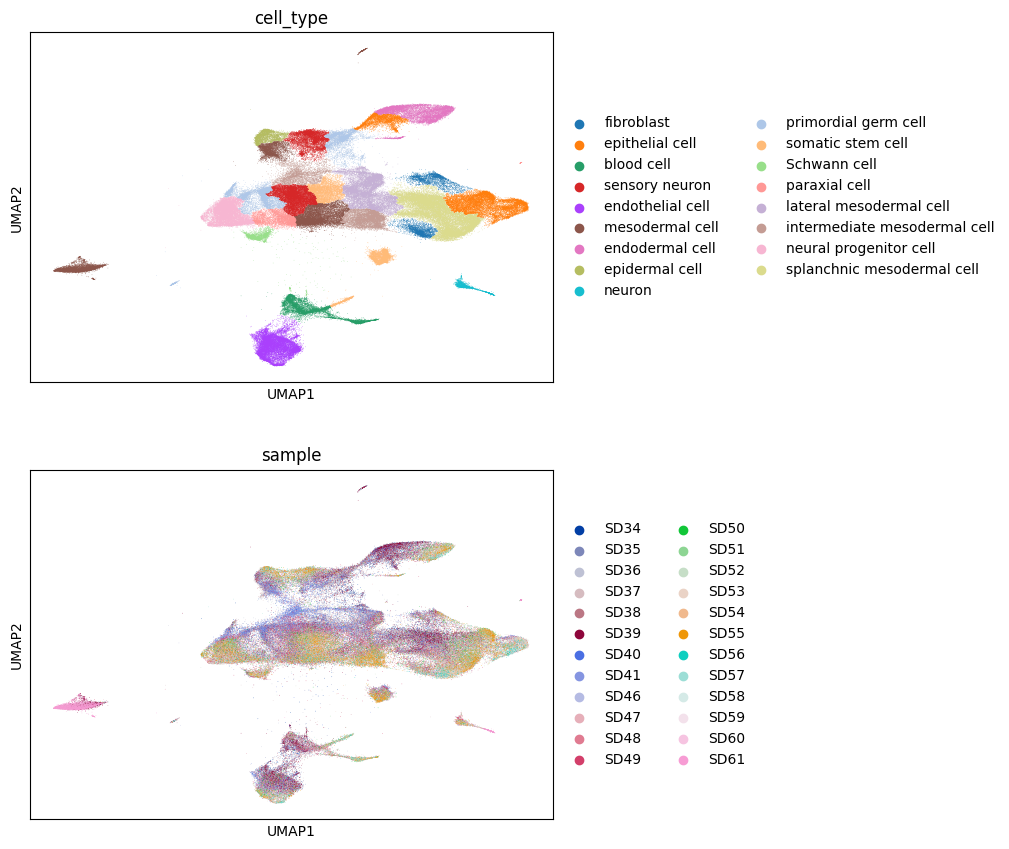

In [33]:
# Plot UMAP if available
if 'X_umap' in adata.obsm:
    sc.pl.umap(adata, color=['cell_type', 'sample'], ncols=1)
else:
    print("No precomputed UMAP found. We'll create one later with gene embeddings.")

In [34]:
donor_col = 'sample' #this is the column that contains the donor IDs, usually it's donorID

n_donors = adata.obs[donor_col].nunique()
print(f"\nNumber of unique donors: {n_donors}")

# Create a cross-tabulation of donor_id and cell_type
donor_cell_matrix = pd.crosstab(adata.obs[donor_col], adata.obs['cell_type'])

# Create heatmap using plotly
import plotly.express as px
import numpy as np

# Apply log10 transform to the data (adding 1 to avoid log(0))
log_data = np.log10(donor_cell_matrix.values + 1)

# Create regular heatmap with log-transformed data
fig = px.imshow(
    log_data,
    labels=dict(x="Cell Type", y="Donor ID", color="Count"),
    x=donor_cell_matrix.columns,
    y=donor_cell_matrix.index,
    color_continuous_scale='Viridis',
    title='Cell Type Distribution Across Donors (Log Scale)',
    aspect='auto'
)

fig.data[0].customdata = donor_cell_matrix.values
fig.data[0].hovertemplate = "Cell Type: %{x}<br>Donor ID: %{y}<br>Count: %{customdata:.0f}<br>Log10 Count: %{z:.2f}<extra></extra>"

tick_values = np.linspace(log_data.min(), log_data.max(), 6)
# Convert tick values back to linear space for labels
tick_labels = [f"{int(10**x - 1)}" for x in tick_values]

fig.update_layout(
    xaxis_title='Cell Type',
    yaxis_title='Donor ID',
    coloraxis=dict(
        colorbar=dict(
            title='Count',
            tickvals=tick_values,
            ticktext=tick_labels
        )
    )
)

from IPython.display import display
display(fig)


Number of unique donors: 24


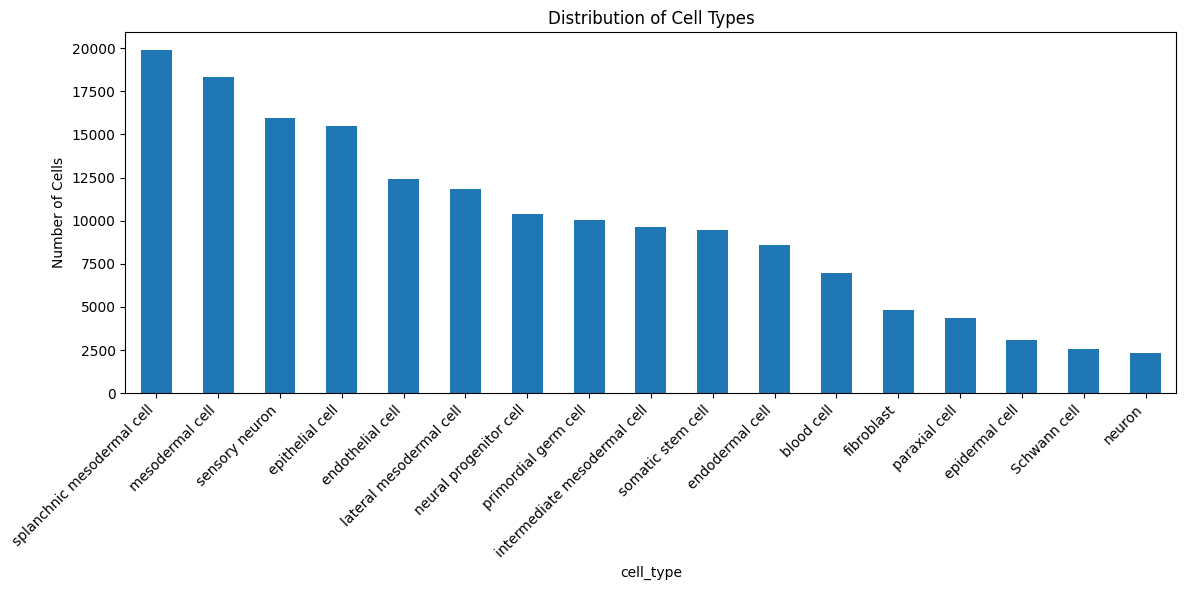

In [17]:
# Visualize cell type distribution
if 'cell_type' in adata.obs:
    plt.figure(figsize=(12, 6))
    adata.obs['cell_type'].value_counts().plot(kind='bar')
    plt.title('Distribution of Cell Types')
    plt.ylabel('Number of Cells')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [35]:
from src.utils import get_gene_embeddings

gene_embedding = get_gene_embeddings("text-embedding-ada-002")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\annel\\OneDrive\\Documenten\\Machine Learning\\scGPT\\data\\GenePT_emebdding_v2\\GenePT_gene_embedding_ada_text.pickle'

In [19]:
print("Type of gene_embedding:", type(gene_embedding))
sample_gene = next(iter(gene_embedding))
print(f"Gene embedding size: {len(gene_embedding)}")
print(f"Gene embedding type: {type(gene_embedding)}")
print(f"Example embedding for {sample_gene}:")
print(f"  Embedding length: {len(gene_embedding[sample_gene])}")
print(f"  Embedding type: {type(gene_embedding[sample_gene])}")

Type of gene_embedding: <class 'dict'>
Gene embedding size: 93800
Gene embedding type: <class 'dict'>
Example embedding for A1BG:
  Embedding length: 1536
  Embedding type: <class 'list'>


In [20]:
for i, (gene, embedding) in enumerate(gene_embedding.items()):
    if i >= 3: break
    print(f"Example embedding for {gene}:")
    print(f"  Embedding length: {len(embedding)}")
    print(f"  First 5 values: {embedding[:5]}")

Example embedding for A1BG:
  Embedding length: 1536
  First 5 values: [-0.04306674003601074, -0.020245488733053207, -0.0021024656016379595, -0.017412150278687477, -0.004771598614752293]
Example embedding for A1BG-AS1:
  Embedding length: 1536
  First 5 values: [-0.027003426104784012, -0.006847249809652567, 0.007299301214516163, -0.025647271424531937, -0.014492237009108067]
Example embedding for A1CF:
  Embedding length: 1536
  First 5 values: [-0.04072963073849678, -0.014075488783419132, 0.006620862986892462, -0.016097526997327805, -0.014863296411931515]


In [21]:
def convert_embeddings_to_dataframe(gene_embedding_dict):
    """
    Convert gene embedding dictionary to a DataFrame
    
    Args:
        gene_embedding_dict: Dictionary with gene names as keys and embedding vectors as values
        
    Returns:
        DataFrame with gene names as index and embedding dimensions as columns
    """
    # Create a DataFrame from the dictionary
    embedding_df = pd.DataFrame.from_dict(gene_embedding_dict, orient='index')
    embedding_df.index.name = 'gene_name'
    
    # Rename columns to have consistent naming
    embedding_df.columns = [f'dim_{i}' for i in range(embedding_df.shape[1])]
    
    return embedding_df

# Convert to DataFrame
gene_embedding_df = convert_embeddings_to_dataframe(gene_embedding)

In [22]:
print(f"Gene embedding DataFrame shape: {gene_embedding_df.shape}")
print(f"First few columns of gene embedding DataFrame:")
display(gene_embedding_df.iloc[:, :5].head()) #show the first 5 dimensions of the first few genes

Gene embedding DataFrame shape: (93800, 1536)
First few columns of gene embedding DataFrame:


,dim_0,dim_1,dim_2,dim_3,dim_4
gene_name,,,,,
A1BG,-0.043067,-0.020245,-0.002102,-0.017412,-0.004772
A1BG-AS1,-0.027003,-0.006847,0.007299,-0.025647,-0.014492
A1CF,-0.040730,-0.014075,0.006621,-0.016098,-0.014863
A2M,-0.029095,-0.001240,-0.015252,-0.025177,-0.012216
A2M-AS1,-0.033439,-0.007015,-0.002068,-0.011076,-0.027708


In [23]:
#change this later to use your annotation script in the my utils folder 

# Get gene names from AnnData object
# Adjust this based on how gene names are stored in your AnnData object
if 'feature_name' in adata.var:
    gene_names = adata.var['feature_name'].values
else:
    gene_names = adata.var_names.to_numpy()

print(f"Number of genes in AnnData: {len(gene_names)}")
print(f"First few gene names: {gene_names[:5]}")

Number of genes in AnnData: 27003
First few gene names: ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112']
Categories (27003, object): ['5S_rRNA_ENSG00000276861', '5S_rRNA_ENSG00000277411', '5S_rRNA_ENSG00000277488', '5S_rRNA_ENSG00000278457', ..., 'ZZEF1', 'ZZZ3', 'hsa-mir-8069-1', 'snoZ196']


In [24]:
genes_in_embedding = set(gene_embedding_df.index)
anndata_genes = set(gene_names)
common_genes = genes_in_embedding.intersection(anndata_genes)

print(f"Number of genes in embeddings: {len(genes_in_embedding)}")
print(f"Number of genes in AnnData: {len(anndata_genes)}")
print(f"Number of common genes: {len(common_genes)}")
print(f"Percentage of AnnData genes with embeddings: {len(common_genes)/len(anndata_genes)*100:.2f}%")

Number of genes in embeddings: 93800
Number of genes in AnnData: 27003
Number of common genes: 24033
Percentage of AnnData genes with embeddings: 89.00%


In [25]:
gene_idx_map = {gene: idx for idx, gene in enumerate(gene_names)}

valid_indices = []
valid_gene_names = []

for gene in common_genes:
    if gene in gene_idx_map:
        valid_indices.append(gene_idx_map[gene])
        valid_gene_names.append(gene)

print(f"Number of valid genes with embeddings: {len(valid_indices)}")

Number of valid genes with embeddings: 24033


In [26]:
# Create the embedding matrix (genes x embedding_dims)
embedding_matrix = gene_embedding_df.loc[valid_gene_names].values

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (24033, 1536)


In [27]:
# Create DataFrame with gene names as index and display
# Create DataFrame with gene names as index
embedding_df = pd.DataFrame(embedding_matrix, index=valid_gene_names, columns=[f'dim_{i}' for i in range(embedding_matrix.shape[1])])
display(embedding_df.iloc[:5, :5].head())


,dim_0,dim_1,dim_2,dim_3,dim_4
SLITRK4,-0.026988,-0.010823,-0.010337,-0.017397,-0.004392
NKX6-2,-0.037207,0.001167,-0.002008,-0.023360,-0.036943
DRC3,-0.026731,-0.010097,-0.005074,-0.035446,-0.019099
NOTCH3,-0.038696,-0.005012,-0.000446,-0.015568,-0.004178
SPIN1,-0.016593,-0.015267,0.003727,-0.006568,-0.017379


In [36]:
def create_cell_embeddings(adata, embedding_matrix, valid_indices, use_layer=None, normalize=True):
    """
    Create cell embeddings from gene expression and gene embeddings
    
    Args:
        adata: AnnData object
        embedding_matrix: Matrix of gene embeddings (genes x embedding_dims)
        valid_indices: Indices of genes in adata that have embeddings
        use_layer: Optional layer to use from adata (e.g., 'normalized')
        normalize: Whether to normalize the cell embeddings (default: True)
        
    Returns:
        Matrix of cell embeddings (cells x embedding_dims)
    """
    print(f"Creating cell embeddings from {len(valid_indices)} genes with embeddings...")
    
    # Get expression matrix
    if use_layer is not None and use_layer in adata.layers:
        print(f"Using expression data from layer: {use_layer}")
        expr_matrix = adata.layers[use_layer]
    else:
        print("Using expression data from adata.X")
        expr_matrix = adata.X
    
    # For very large datasets, we might need to preprocess to reduce memory usage
    n_cells = expr_matrix.shape[0]
    n_embedding_dims = embedding_matrix.shape[1]
    
    # Check if we're dealing with a very large dataset (> 50k cells or > 10k genes)
    is_large_dataset = n_cells > 50000 or len(valid_indices) > 10000
    
    # Memory-efficient processing for large datasets
    if sparse.issparse(expr_matrix) or is_large_dataset:
        print(f"Processing large dataset with {n_cells} cells in chunks...")
        cell_embeddings = np.zeros((n_cells, n_embedding_dims))
        
        # Adjust chunk size based on dataset size
        chunk_size = 500 if n_cells > 100000 else 1000
        
        # Process in chunks
        for i in range(0, n_cells, chunk_size):
            end = min(i + chunk_size, n_cells)
            if sparse.issparse(expr_matrix):
                chunk = expr_matrix[i:end, valid_indices].toarray()
            else:
                chunk = expr_matrix[i:end, valid_indices]
                
            # Perform matrix multiplication for this chunk
            cell_embeddings[i:end] = chunk @ embedding_matrix
            
            # Print progress
            if (i // chunk_size) % 10 == 0:
                print(f"Processed {i}/{n_cells} cells ({i/n_cells*100:.1f}%)...")
    else:
        # For smaller datasets, process all at once
        print("Processing expression matrix all at once...")
        expr_filtered = expr_matrix[:, valid_indices]
        if sparse.issparse(expr_filtered):
            expr_filtered = expr_filtered.toarray()
        cell_embeddings = expr_filtered @ embedding_matrix
    
    # Normalize the cell embeddings
    if normalize:
        print("Normalizing cell embeddings...")
        norms = np.linalg.norm(cell_embeddings, axis=1, keepdims=True)
        # Avoid division by zero
        norms[norms < 1e-10] = 1.0
        cell_embeddings = cell_embeddings / norms
        print("Normalization complete.")
    
    print(f"Created cell embeddings with shape: {cell_embeddings.shape}")
    return cell_embeddings

In [37]:
def create_cell_embeddings_memory_efficient(adata, embedding_matrix, valid_indices, use_layer=None, 
                                  output_file='cell_embeddings.h5ad', batch_size=1000, dtype='float32'):
    """
    Memory-efficient version that processes and saves cell embeddings in batches without 
    keeping the entire matrix in memory.
    
    Args:
        adata: AnnData object
        embedding_matrix: Matrix of gene embeddings (genes x embedding_dims)
        valid_indices: Indices of genes in adata that have embeddings
        use_layer: Optional layer to use from adata (e.g., 'normalized')
        output_file: Path to save the partial results
        batch_size: Number of cells to process at once
        dtype: Data type to use for embeddings (float32 uses half the memory of float64)
        
    Returns:
        Path to the saved embeddings
    """
    from scipy import sparse
    import h5py
    import os
    
    print(f"Creating cell embeddings with memory-efficient processing...")
    print(f"Using {dtype} data type instead of float64 to save memory")
    
    # Get expression matrix
    if use_layer is not None and use_layer in adata.layers:
        print(f"Using expression data from layer: {use_layer}")
        expr_matrix = adata.layers[use_layer]
    else:
        print("Using expression data from adata.X")
        expr_matrix = adata.X
    
    # For very large datasets, we process in small batches and save to disk
    n_cells = expr_matrix.shape[0]
    n_embedding_dims = embedding_matrix.shape[1]
    
    print(f"Processing {n_cells} cells with {n_embedding_dims} embedding dimensions")
    print(f"Processing in batches of {batch_size} cells")
    
    # Convert embedding matrix to the more memory-efficient data type
    embedding_matrix = embedding_matrix.astype(dtype)
    
    # Create h5 file to store results
    with h5py.File(output_file, 'w') as f:
        # Create a dataset to hold all embeddings
        dset = f.create_dataset('cell_embeddings', shape=(n_cells, n_embedding_dims), dtype=dtype)
        
        # Also save the cell IDs for reference
        cell_ids = adata.obs_names.values.astype('S')  # Convert to byte strings for h5py
        f.create_dataset('cell_ids', data=cell_ids)
        
        # Process in small batches
        for i in range(0, n_cells, batch_size):
            end = min(i + batch_size, n_cells)
            print(f"Processing cells {i} to {end} ({(i/n_cells*100):.1f}% complete)")
            
            # Get this batch of cells
            if sparse.issparse(expr_matrix):
                chunk = expr_matrix[i:end, valid_indices].toarray().astype(dtype)
            else:
                chunk = expr_matrix[i:end, valid_indices].astype(dtype)
            
            # Generate embeddings for this batch
            batch_embeddings = chunk @ embedding_matrix
            
            # Normalize if needed (within the batch)
            norms = np.linalg.norm(batch_embeddings, axis=1, keepdims=True)
            norms[norms < 1e-10] = 1.0
            batch_embeddings = batch_embeddings / norms
            
            # Save to our h5 dataset
            dset[i:end, :] = batch_embeddings
            
            # Force garbage collection to free memory
            del batch_embeddings
            del chunk
            import gc
            gc.collect()
    
    print(f"Cell embeddings saved to {output_file}")
    return output_file

# Function to load partial embeddings for UMAP or other analysis
def load_cell_embeddings_sample(embeddings_file, max_cells=10000, random_seed=42):
    """
    Load a random sample of cell embeddings for analysis
    
    Args:
        embeddings_file: Path to h5 file with saved embeddings
        max_cells: Maximum number of cells to load
        random_seed: Random seed for reproducibility
        
    Returns:
        Tuple of (sampled_embeddings, sampled_cell_ids)
    """
    import h5py
    import numpy as np
    
    print(f"Loading sample of max {max_cells} cells from {embeddings_file}")
    
    with h5py.File(embeddings_file, 'r') as f:
        total_cells = f['cell_embeddings'].shape[0]
        print(f"File contains {total_cells} cells")
        
        # Determine sampling strategy
        if total_cells <= max_cells:
            # If we have fewer cells than max, load all of them
            embeddings = f['cell_embeddings'][:]
            cell_ids = f['cell_ids'][:]
        else:
            # Otherwise sample randomly
            np.random.seed(random_seed)
            indices = np.random.choice(total_cells, max_cells, replace=False)
            indices.sort()  # Sort for more efficient reading
            
            embeddings = f['cell_embeddings'][indices]
            cell_ids = f['cell_ids'][indices]
            
    # Convert byte strings back to regular strings
    cell_ids = [id.decode('utf-8') for id in cell_ids]
    
    print(f"Loaded {len(cell_ids)} cells")
    return embeddings, cell_ids

# First, create and save the embeddings in a memory-efficient way
embeddings_file = create_cell_embeddings_memory_efficient(
    adata, 
    embedding_matrix, 
    valid_indices,
    output_file='embryoid_cell_embeddings.h5',
    batch_size=500  # Process 500 cells at a time to conserve memory
)

# Later, load a sample for UMAP or other analyses
sample_embeddings, sample_cell_ids = load_cell_embeddings_sample(
    embeddings_file, 
    max_cells=10000  # Only load 10,000 cells for visualization/analysis
)

# Now you can run UMAP on the sample
reducer = umap.UMAP(random_state=42)
umap_embeddings = reducer.fit_transform(sample_embeddings)

# Create DataFrame with results
umap_df = pd.DataFrame(
    umap_embeddings,
    columns=["UMAP1", "UMAP2"],
    index=sample_cell_ids
)

# Add metadata
for col in ['cell_type', 'time.point', 'line', 'cluster']:
    if col in adata.obs:
        umap_df[col] = adata.obs.loc[umap_df.index, col].values

# Create plot
import plotly.express as px
fig = px.scatter(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    color='cell_type' if 'cell_type' in umap_df else 'cluster',
    opacity=0.7,
    title="UMAP of Cell Embeddings (Sampled Subset)"
)
fig.show()

NameError: name 'embedding_matrix' is not defined

In [38]:
cell_embeddings, sample_cell_ids = load_cell_embeddings_sample(
    embeddings_file, 
    max_cells=len(adata.obs_names)  # Load all cells by getting the total number of cells
)

cell_embedding_df = pd.DataFrame(
    cell_embeddings,
    index=adata.obs_names,
    columns=[f'embed_{i}' for i in range(cell_embeddings.shape[1])]
)

print("Cell embedding DataFrame created.")
#print(f"Shape: {embeddings_file.shape}")
print(f"First few values:")
print(cell_embedding_df.iloc[:3, :5])

Loading sample of max 166085 cells from embryoid_cell_embeddings.h5
File contains 166085 cells
Loaded 166085 cells
Cell embedding DataFrame created.
First few values:
    embed_0   embed_1   embed_2   embed_3   embed_4
0 -0.037623 -0.012959 -0.005060 -0.023255 -0.021746
1 -0.037462 -0.011792 -0.003999 -0.023240 -0.021649
2 -0.037751 -0.012626 -0.005058 -0.023313 -0.022103


In [ ]:
#this is to store them in the adata object
#adata.obsm['X_gene_embeddings'] = cell_embeddings
# Display the gene embeddings stored in obsm



Shape of X_scGPT: (166085, 512)

First 5 rows and 5 columns of X_scGPT:
[[ 0.03102008 -0.00180276 -0.00774173  0.01752995  0.07491258]
 [-0.01782434  0.0690792  -0.00795162 -0.00896409 -0.04698454]
 [-0.02148473 -0.00099047 -0.01411769 -0.0004235   0.0195812 ]
 [-0.0132132   0.0241119   0.04149374  0.01795445  0.0234308 ]
 [-0.03145679  0.00874467 -0.03223879 -0.03133109  0.04370971]]
scGPT embeddings DataFrame created.
Shape: (166085, 512)
First few rows:


,scgpt_dim_0,scgpt_dim_1,scgpt_dim_2,scgpt_dim_3,scgpt_dim_4,scgpt_dim_5,scgpt_dim_6,scgpt_dim_7,scgpt_dim_8,scgpt_dim_9,...,scgpt_dim_502,scgpt_dim_503,scgpt_dim_504,scgpt_dim_505,scgpt_dim_506,scgpt_dim_507,scgpt_dim_508,scgpt_dim_509,scgpt_dim_510,scgpt_dim_511
0,0.031020,-0.001803,-0.007742,0.017530,0.074913,0.009873,0.004874,0.004252,0.032461,0.057684,...,-0.034146,-0.030187,-0.007740,-0.032067,0.017423,-0.030023,0.030961,0.010100,-0.035616,-0.029478
1,-0.017824,0.069079,-0.007952,-0.008964,-0.046985,-0.005998,0.015482,0.027172,0.018819,-0.007388,...,0.006731,-0.006831,0.032551,-0.012131,0.038937,-0.018630,-0.024227,-0.036894,-0.004328,-0.067847
2,-0.021485,-0.000990,-0.014118,-0.000423,0.019581,-0.031083,0.015800,0.004231,0.048519,-0.026439,...,0.004872,0.040514,-0.018505,0.039967,0.008802,0.027044,-0.036491,0.026015,-0.012655,-0.028260
3,-0.013213,0.024112,0.041494,0.017954,0.023431,-0.037096,-0.004955,-0.000374,0.066538,0.134639,...,-0.030534,-0.020800,0.014101,-0.039153,-0.013018,-0.031527,-0.010538,-0.034061,-0.029804,-0.016320
4,-0.031457,0.008745,-0.032239,-0.031331,0.043710,0.037802,-0.043058,-0.023051,-0.002183,0.035126,...,-0.016420,-0.022151,0.006408,0.019784,0.007498,-0.020903,0.026966,-0.010567,-0.031627,0.006476


# Analysis of embeddings

In [24]:
filepath = Path(r"C:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\data\Derived_Embryoid_Bodies_Finetuned_Embed_202701.h5ad")
adata = sc.read_h5ad(filepath)

print("Shape of X_scGPT:", adata.obsm['X_scGPT'].shape)
print("\nFirst 5 rows and 5 columns of X_scGPT:")
print(adata.obsm['X_scGPT'][:5, :5])
# Create DataFrame from X_scGPT embeddings
scgpt_embeddings_df = pd.DataFrame(
    adata.obsm['X_scGPT'],
    index=adata.obs_names,
    columns=[f'scgpt_dim_{i}' for i in range(adata.obsm['X_scGPT'].shape[1])]
)

print("scGPT embeddings DataFrame created.")
print(f"Shape: {scgpt_embeddings_df.shape}")
print(f"First few rows:")
display(scgpt_embeddings_df.head())








Shape of X_scGPT: (166085, 512)

First 5 rows and 5 columns of X_scGPT:
[[ 0.03102008 -0.00180276 -0.00774173  0.01752995  0.07491258]
 [-0.01782434  0.0690792  -0.00795162 -0.00896409 -0.04698454]
 [-0.02148473 -0.00099047 -0.01411769 -0.0004235   0.0195812 ]
 [-0.0132132   0.0241119   0.04149374  0.01795445  0.0234308 ]
 [-0.03145679  0.00874467 -0.03223879 -0.03133109  0.04370971]]
scGPT embeddings DataFrame created.
Shape: (166085, 512)
First few rows:


,scgpt_dim_0,scgpt_dim_1,scgpt_dim_2,scgpt_dim_3,scgpt_dim_4,scgpt_dim_5,scgpt_dim_6,scgpt_dim_7,scgpt_dim_8,scgpt_dim_9,...,scgpt_dim_502,scgpt_dim_503,scgpt_dim_504,scgpt_dim_505,scgpt_dim_506,scgpt_dim_507,scgpt_dim_508,scgpt_dim_509,scgpt_dim_510,scgpt_dim_511
0,0.031020,-0.001803,-0.007742,0.017530,0.074913,0.009873,0.004874,0.004252,0.032461,0.057684,...,-0.034146,-0.030187,-0.007740,-0.032067,0.017423,-0.030023,0.030961,0.010100,-0.035616,-0.029478
1,-0.017824,0.069079,-0.007952,-0.008964,-0.046985,-0.005998,0.015482,0.027172,0.018819,-0.007388,...,0.006731,-0.006831,0.032551,-0.012131,0.038937,-0.018630,-0.024227,-0.036894,-0.004328,-0.067847
2,-0.021485,-0.000990,-0.014118,-0.000423,0.019581,-0.031083,0.015800,0.004231,0.048519,-0.026439,...,0.004872,0.040514,-0.018505,0.039967,0.008802,0.027044,-0.036491,0.026015,-0.012655,-0.028260
3,-0.013213,0.024112,0.041494,0.017954,0.023431,-0.037096,-0.004955,-0.000374,0.066538,0.134639,...,-0.030534,-0.020800,0.014101,-0.039153,-0.013018,-0.031527,-0.010538,-0.034061,-0.029804,-0.016320
4,-0.031457,0.008745,-0.032239,-0.031331,0.043710,0.037802,-0.043058,-0.023051,-0.002183,0.035126,...,-0.016420,-0.022151,0.006408,0.019784,0.007498,-0.020903,0.026966,-0.010567,-0.031627,0.006476


In [25]:
print (adata)

AnnData object with n_obs × n_vars = 166085 × 26232
    obs: 'nCount_RNA', 'nFeature_RNA', 'Size_Factor', 'n.umi', 'scrublet_score', 'scrublet_call', 'sample', 'Ligation_barcode', 'RT_barcode', 'P7_barcode', 'P5_barcode', 'line', 'line_and_time.point', 'time.point', 'perc_mito_umi', 'monocle_cluster', 'sex_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_type', 'is_primary_data', 'cluster', 'Xu_S1B_max_cell_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'id_in_vocab'
    uns: 'citation', 'default_embedding', 'schema_reference', 'schema_version', 'tit

In [26]:
print("Available Batch IDs:")
print(adata.obs['sample'].unique())

# Verify column names in observations
print("Available observation columns:")
print(adata.obs.columns)

# Select test donors (first 3 by default)
test_donors = adata.obs['sample'].unique()[[6,7,8]]  # Take donors at indices 6,7,8
print(f"Using donors for testing: {test_donors}")

Available Batch IDs:
['SD34', 'SD35', 'SD36', 'SD37', 'SD38', ..., 'SD57', 'SD58', 'SD59', 'SD60', 'SD61']
Length: 24
Categories (24, object): ['SD34', 'SD35', 'SD36', 'SD37', ..., 'SD58', 'SD59', 'SD60', 'SD61']
Available observation columns:
Index(['nCount_RNA', 'nFeature_RNA', 'Size_Factor', 'n.umi', 'scrublet_score',
       'scrublet_call', 'sample', 'Ligation_barcode', 'RT_barcode',
       'P7_barcode', 'P5_barcode', 'line', 'line_and_time.point', 'time.point',
       'perc_mito_umi', 'monocle_cluster', 'sex_ontology_term_id', 'donor_id',
       'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type',
       'assay_ontology_term_id', 'disease_ontology_term_id',
       'cell_type_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'suspension_type',
       'is_primary_data', 'cluster', 'Xu_S1B_max_cell_type', 'cell_type',
       'assay', 'disease', 'organism', 'sex', 'tissue',
       'self_reported_ethnici

In [27]:
X = pd.DataFrame(adata.obsm['X_scGPT'], index=adata.obs.index)
X['sample'] = adata.obs['sample']
y = adata.obs['cell_type']

# Check for and remove "To be predicted" samples if they exist
if "To be predicted" in y.unique():
    mask = y != "To be predicted"
    X = X[mask]
    y = y[mask]

print("Initial data:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nDonor distribution:")
print(X['sample'].value_counts())
print("\nCell type distribution:")
print(y.value_counts())

Initial data:
X shape: (166085, 513)
y shape: (166085,)

Donor distribution:
sample
SD37    13949
SD38    12428
SD39    12357
SD49    10799
SD36    10527
SD47     9709
SD34     8976
SD41     8796
SD35     8785
SD52     8763
SD48     8411
SD54     7558
SD46     7474
SD40     7297
SD51     7296
SD53     6110
SD55     5162
SD50     4971
SD61     3943
SD57     1312
SD56     1157
SD58      272
SD60       30
SD59        3
Name: count, dtype: int64

Cell type distribution:
cell_type
splanchnic mesodermal cell      19921
mesodermal cell                 18299
sensory neuron                  15966
epithelial cell                 15494
endothelial cell                12399
lateral mesodermal cell         11823
neural progenitor cell          10381
primordial germ cell            10040
intermediate mesodermal cell     9629
somatic stem cell                9473
endodermal cell                  8571
blood cell                       6960
fibroblast                       4845
paraxial cell            

In [28]:
results = []
for test_donor in test_donors:
    print(f"\n=== Cross Validation Fold: Testing on Donor {test_donor} ===")

    # Create initial train/test split based on donor
    train_mask = X['sample'] != test_donor
    test_indices = X[~train_mask].index
    print (test_indices, train_mask)

    # Subsample training data (1000 samples per cell type or less if fewer available)
    train_indices = []
    for class_label in y.unique():
        # Get indices for this class from non-test donors
        class_mask = (X['sample'] != test_donor) & (y == class_label)
        class_indices = X[class_mask].index
        
        print(f"\nClass: {class_label}")
        print(f"Total samples: {len(class_indices)}")
        
        # Sample up to 1000 indices
        if len(class_indices) > 0:
            n_samples = min(1000, len(class_indices))
            sampled_indices = np.random.choice(class_indices, size=n_samples, replace=False)
            train_indices.extend(sampled_indices)
        else:
            print(f"Warning: class '{class_label}' has no samples!")

    # Create the final train/test splits
    X_train = X.drop(columns=["sample"]).loc[train_indices]
    X_test = X.drop(columns=["sample"]).loc[test_indices]
    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]

    print(f"\nTraining set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    print("\nTraining class distribution:")
    print(y_train.value_counts())

    # Train and evaluate models
    models = {
        "KNN": KNeighborsClassifier(n_neighbors=10),
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
    }
    
    # Only use LightGBM if available
    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(random_state=42, class_weight="balanced")
    except ImportError:
        print("LightGBM not available, skipping this model")

    for name, model in models.items():
        print(f"\n{'-'*20} {name} Results {'-'*20}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Generate and store results
        report = classification_report(
            y_test,
            y_pred,
            zero_division=0,
            output_dict=True
        )
        
        results.append({
            "test_donor": test_donor,
            "model": name,
            "macro_avg_f1": report["macro avg"]["f1-score"],
            "weighted_avg_f1": report["weighted avg"]["f1-score"],
            "train_size": len(X_train),
            "test_size": len(X_test)
        })

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

# Show final results
results_df = pd.DataFrame(results)
print("\nSummary of Results:")
print(results_df.round(3))


=== Cross Validation Fold: Testing on Donor SD40 ===
Index(['67022', '67023', '67024', '67025', '67026', '67027', '67028', '67029',
       '67030', '67031',
       ...
       '74309', '74310', '74311', '74312', '74313', '74314', '74315', '74316',
       '74317', '74318'],
      dtype='object', length=7297) 0         True
1         True
2         True
3         True
4         True
          ... 
166080    True
166081    True
166082    True
166083    True
166084    True
Name: sample, Length: 166085, dtype: bool

Class: endothelial cell
Total samples: 11796

Class: mesodermal cell
Total samples: 17761

Class: lateral mesodermal cell
Total samples: 11036

Class: endodermal cell
Total samples: 8468

Class: paraxial cell
Total samples: 4151

Class: primordial germ cell
Total samples: 9241

Class: somatic stem cell
Total samples: 9037

Class: splanchnic mesodermal cell
Total samples: 19432

Class: sensory neuron
Total samples: 14644

Class: fibroblast
Total samples: 4697

Class: blood cell
T

In [29]:
print("\nAverage Performance by Model:")
model_summary = results_df.groupby('model')[['macro_avg_f1', 'weighted_avg_f1']].mean()
print(model_summary.round(3))


Average Performance by Model:
               macro_avg_f1  weighted_avg_f1
model                                       
KNN                   0.668            0.707
LightGBM              0.688            0.723
Random Forest         0.686            0.723


In [9]:
#Optional: save results to csv
#results_df.to_csv(data_dir / 'gene_embedding_classification_results_finetuned.csv', index=False)


In [10]:
def plot_simple_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Create and display a simple confusion matrix.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    title : str
        Title for the plot
    """
    # Create confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Get unique class labels
    classes = sorted(list(set(y_true) | set(y_pred)))
    
    # Create figure and plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    # Add labels and title
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.show()

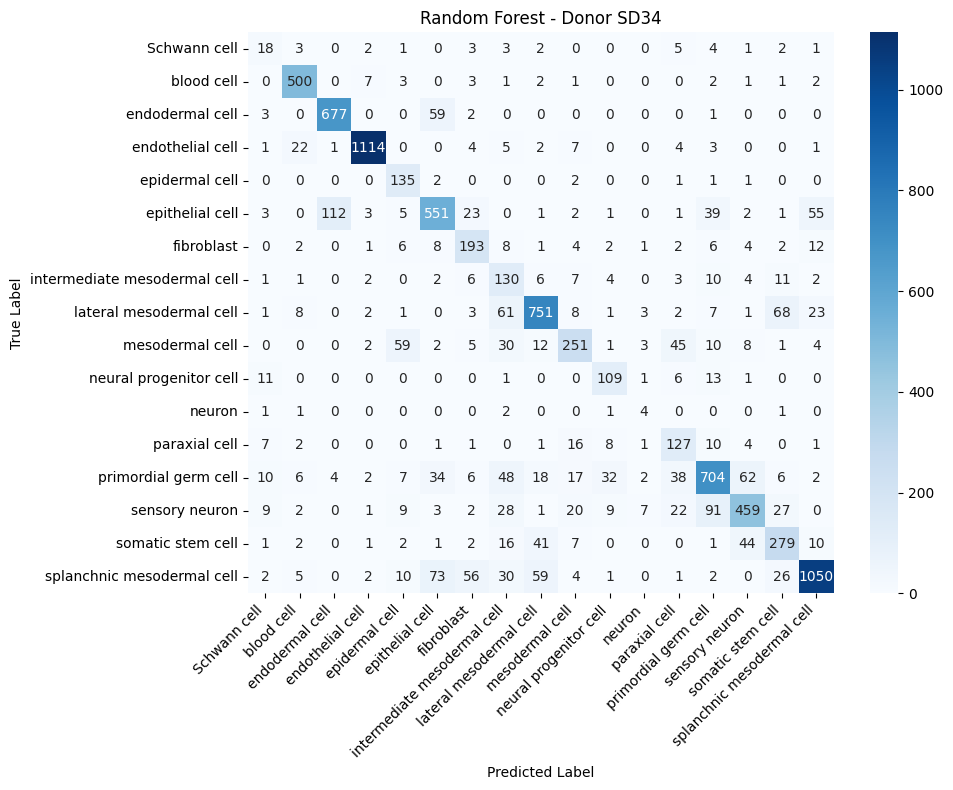

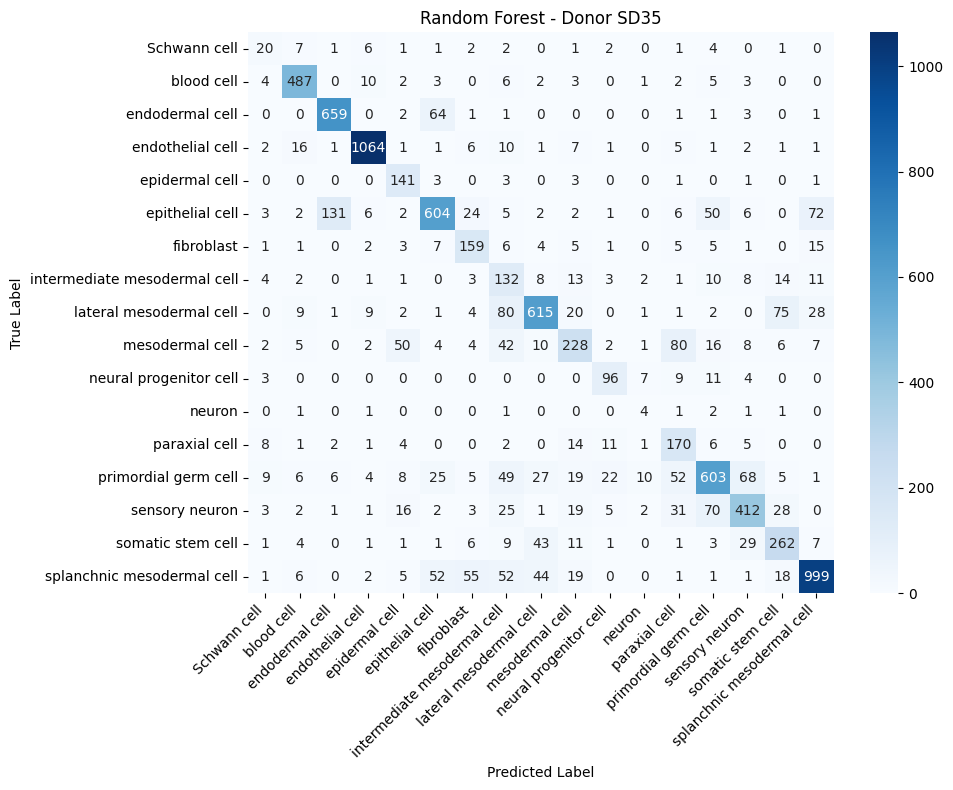

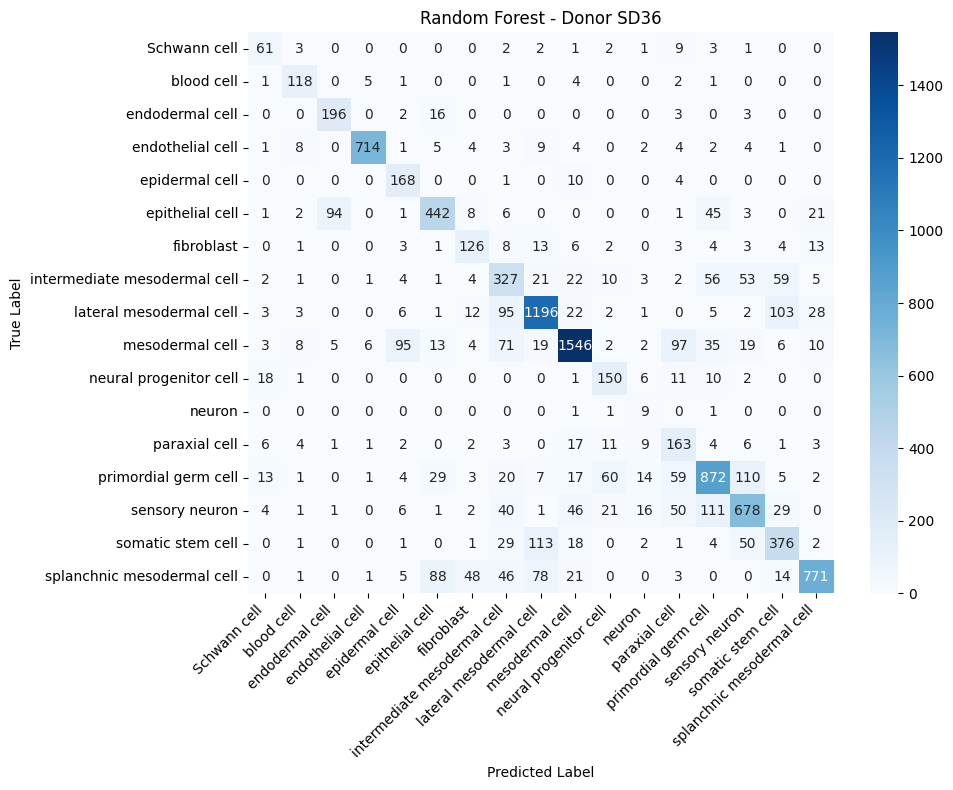

In [11]:
# Generate confusion matrices for each test donor and model
for test_donor in test_donors:
    # Create train/test split again for this donor
    train_mask = X['sample'] != test_donor
    test_indices = X[~train_mask].index
    
    # Repeat the same subsampling process to get the same train/test split
    train_indices = []
    for class_label in y.unique():
        class_mask = (X['sample'] != test_donor) & (y == class_label)
        class_indices = X[class_mask].index
        if len(class_indices) > 0:
            n_samples = min(1000, len(class_indices))
            sampled_indices = np.random.choice(class_indices, size=n_samples, replace=False)
            train_indices.extend(sampled_indices)
    
    # Recreate the same X_train, X_test, y_train, y_test
    X_train = X.drop(columns=["sample"]).loc[train_indices]
    X_test = X.drop(columns=["sample"]).loc[test_indices]
    y_train = y.loc[train_indices]
    y_test = y.loc[test_indices]
    
    # Choose a model and get predictions
    model_name = "Random Forest"  # Change to "KNN" or "LightGBM" if needed
    
    if model_name == "Random Forest":
        model = RandomForestClassifier(random_state=42, n_estimators=100)
    elif model_name == "KNN":
        model = KNeighborsClassifier(n_neighbors=10)
    elif model_name == "LightGBM":
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(random_state=42, class_weight="balanced")
    
    # Fit and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Plot confusion matrix
    plot_simple_confusion_matrix(y_test, y_pred, 
                                title=f"{model_name} - Donor {test_donor}")


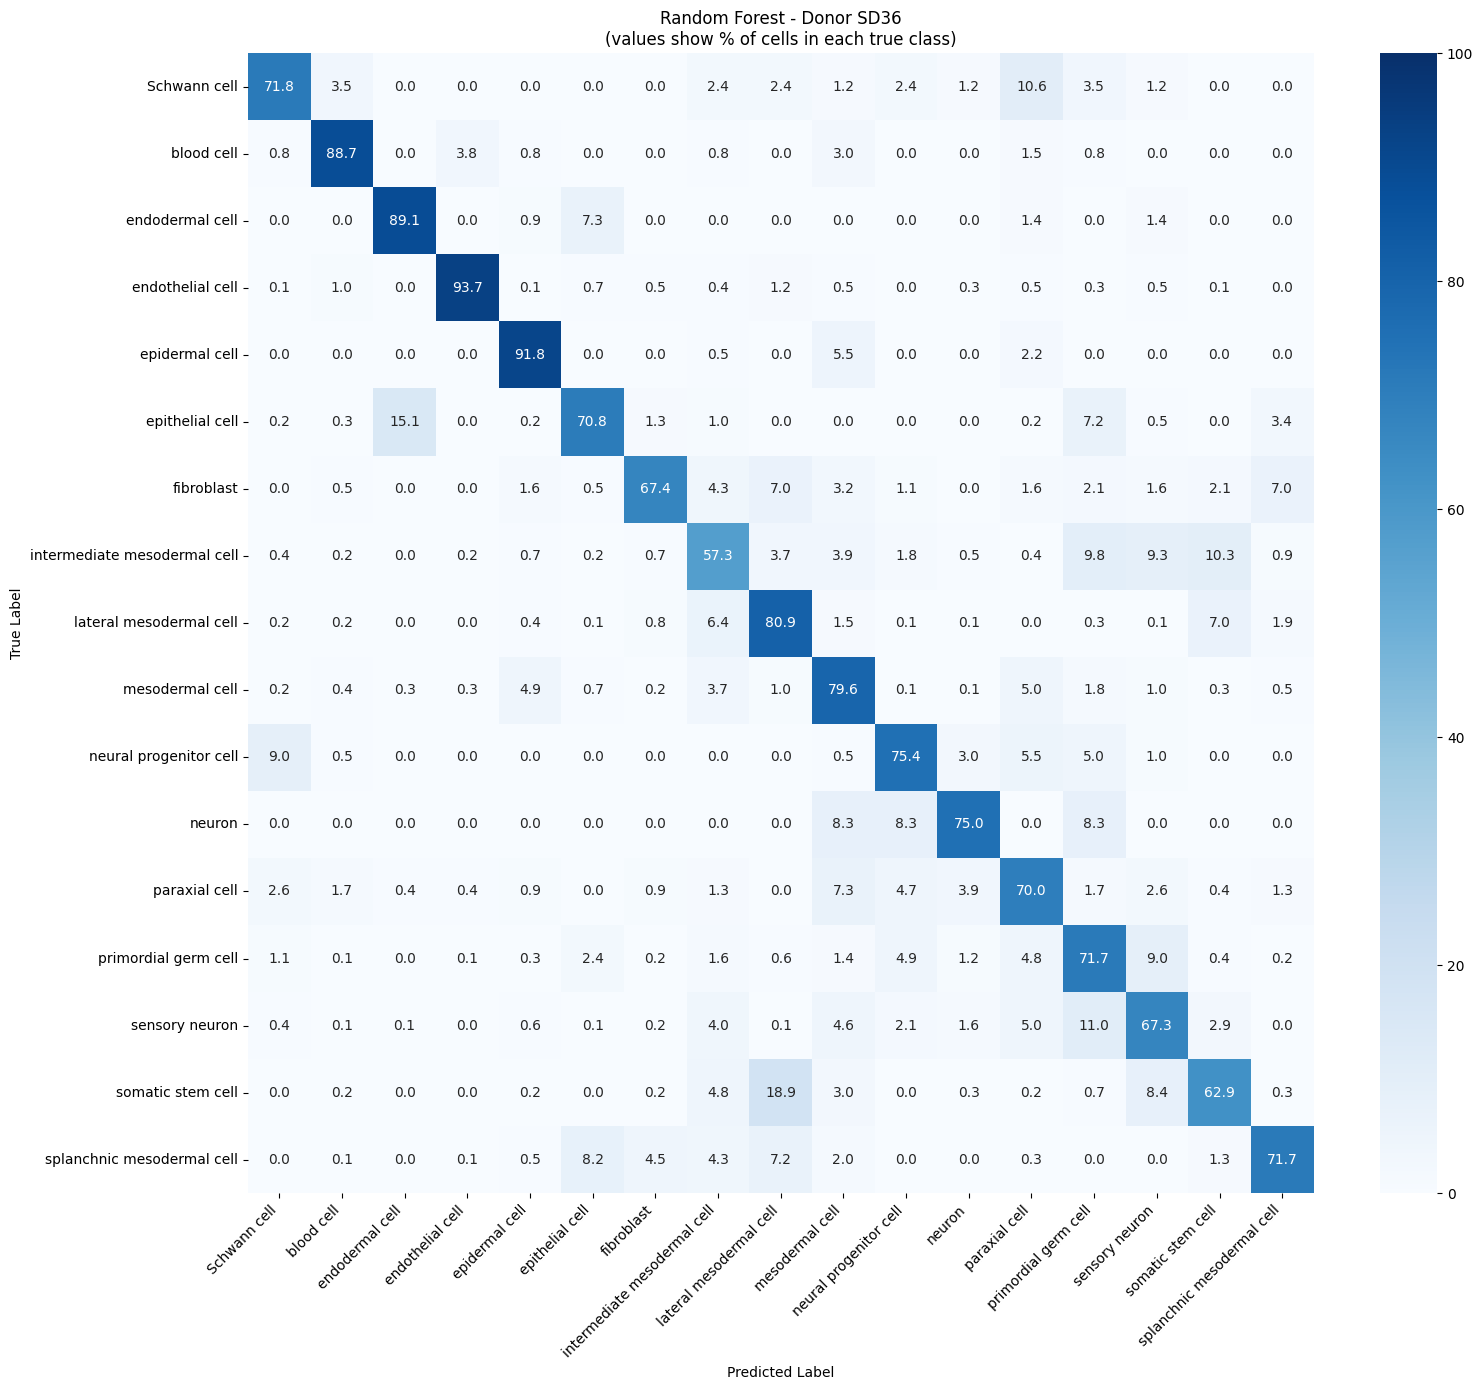

Overall accuracy: 75.2%

Per-class recall (sensitivity):
Schwann cell: 71.8%
blood cell: 88.7%
endodermal cell: 89.1%
endothelial cell: 93.7%
epidermal cell: 91.8%
epithelial cell: 70.8%
fibroblast: 67.4%
intermediate mesodermal cell: 57.3%
lateral mesodermal cell: 80.9%
mesodermal cell: 79.6%
neural progenitor cell: 75.4%
neuron: 75.0%
paraxial cell: 70.0%
primordial germ cell: 71.7%
sensory neuron: 67.3%
somatic stem cell: 62.9%
splanchnic mesodermal cell: 71.7%


In [12]:
def plot_simplified_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Create and display a simplified confusion matrix with percentages
    """
    # Get unique classes ordered by frequency
    classes = sorted(list(set(y_true) | set(y_pred)))
    
    # Create confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    # Convert to percentages (row-normalized)
    cm_percentage = np.zeros(cm.shape)
    for i in range(cm.shape[0]):
        row_sum = np.sum(cm[i, :])
        if row_sum > 0:
            cm_percentage[i, :] = (cm[i, :] / row_sum) * 100
    
    # Create figure
    plt.figure(figsize=(16, 14))
    
    # Create heatmap with percentages
    sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, vmin=0, vmax=100)
    
    # Add labels
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{title}\n(values show % of cells in each true class)')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()
    
    # Print accuracy
    accuracy = np.sum(np.diag(cm)) / np.sum(cm) * 100
    print(f"Overall accuracy: {accuracy:.1f}%")
    
    # Print per-class metrics
    print("\nPer-class recall (sensitivity):")
    for i, c in enumerate(classes):
        recall = cm[i, i] / np.sum(cm[i, :]) * 100 if np.sum(cm[i, :]) > 0 else 0
        print(f"{c}: {recall:.1f}%")

# Example usage with the last test donor
plot_simplified_confusion_matrix(y_test, y_pred, title=f"{model_name} - Donor {test_donor}")

### Advanced Embedding Analysis & Classification Evaluation
 
This section performs a comprehensive analysis of the gene embeddings to:
1. Evaluate embedding quality with quantitative metrics
2. Compare embedding performance
3. Analyze classification performance in detail
4. Identify important embedding dimensions
5. Visualize error patterns

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go

print("Starting advanced embedding analysis...")

Starting advanced embedding analysis...


In [16]:
def calculate_embedding_quality(adata, embedding_key='X_scGPT', label_key='cell_type'):
    """Calculate quantitative metrics for embedding quality"""
    embeddings = adata.obsm[embedding_key]
    labels = adata.obs[label_key]
    
    # Calculate silhouette score (higher = better cluster separation)
    sil_score = silhouette_score(embeddings, labels)
    
    # Calculate batch effect score using donor information
    donor_effect = None
    if 'sample' in adata.obs:
        donors = adata.obs['sample']
        # Lower donor silhouette = less donor batch effect
        donor_effect = silhouette_score(embeddings, donors)
    
    # Calculate average distance to same-class cells vs different-class cells
    unique_labels = np.unique(labels)
    within_class_distances = []
    between_class_distances = []
    
    # Sample cells for efficiency (if dataset is large)
    n_sample = min(5000, len(embeddings))
    sample_indices = np.random.choice(len(embeddings), n_sample, replace=False)
    sample_embeddings = embeddings[sample_indices]
    sample_labels = labels.iloc[sample_indices]
    
    # Calculate distances
    from sklearn.metrics.pairwise import euclidean_distances
    dist_matrix = euclidean_distances(sample_embeddings)
    
    for i in range(n_sample):
        current_label = sample_labels.iloc[i]
        # Get indices of same-class and different-class cells
        same_class = np.where(sample_labels == current_label)[0]
        diff_class = np.where(sample_labels != current_label)[0]
        
        # Exclude self from same_class
        same_class = same_class[same_class != i]
        
        # Calculate average distances
        if len(same_class) > 0:
            within_class_distances.append(np.mean(dist_matrix[i, same_class]))
        if len(diff_class) > 0:
            between_class_distances.append(np.mean(dist_matrix[i, diff_class]))
    
    # Calculate separation ratio (higher = better)
    separation_ratio = np.mean(between_class_distances) / np.mean(within_class_distances)
    
    return {
        'silhouette_score': sil_score,
        'donor_effect_score': donor_effect,
        'within_class_distance': np.mean(within_class_distances),
        'between_class_distance': np.mean(between_class_distances),
        'separation_ratio': separation_ratio
    }

# Calculate metrics
quality_metrics = calculate_embedding_quality(adata)
print("Embedding quality metrics:")
for metric, value in quality_metrics.items():
    if value is not None:
        print(f"  {metric}: {value:.4f}")

Embedding quality metrics:
  silhouette_score: 0.0964
  donor_effect_score: -0.1001
  within_class_distance: 0.6546
  between_class_distance: 0.9748
  separation_ratio: 1.4890


In [17]:
# Compare with PCA as baseline (if available)
if 'X_pca' in adata.obsm:
    pca_metrics = calculate_embedding_quality(adata, embedding_key='X_pca')
    print("\nPCA embedding quality metrics:")
    for metric, value in pca_metrics.items():
        if value is not None:
            print(f"  {metric}: {value:.4f}")
    
    # Calculate improvement ratios
    print("\nImprovement ratios (Gene Embeddings vs PCA):")
    improvement = {}
    for metric in ['silhouette_score', 'separation_ratio']:
        if metric in quality_metrics and metric in pca_metrics:
            ratio = quality_metrics[metric] / pca_metrics[metric]
            improvement[metric] = ratio
            print(f"  {metric}: {ratio:.2f}x improvement")
    
    # For donor effect, lower is better
    if 'donor_effect_score' in quality_metrics and 'donor_effect_score' in pca_metrics:
        ratio = pca_metrics['donor_effect_score'] / quality_metrics['donor_effect_score']
        improvement['donor_effect_reduction'] = ratio
        print(f"  donor_effect_reduction: {ratio:.2f}x improvement")
else:
    print("\nPCA embedding not available for comparison")


PCA embedding quality metrics:
  silhouette_score: 0.0144
  donor_effect_score: -0.0466
  within_class_distance: 18.7588
  between_class_distance: 23.3044
  separation_ratio: 1.2423

Improvement ratios (Gene Embeddings vs PCA):
  silhouette_score: 6.69x improvement
  separation_ratio: 1.20x improvement
  donor_effect_reduction: 0.47x improvement


In [18]:
def analyze_embedding_dimensions(X, y, embedding_matrix, n_top_dims=20):
    """Identify and analyze important embedding dimensions using Random Forest feature importance"""
    # Train Random Forest to get feature importances - This could be changed of course! Or do a PCA analysis
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    # Get feature importances
    importances = rf.feature_importances_
    std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'dimension': np.arange(len(importances)),
        'importance': importances,
        'std': std
    }).sort_values('importance', ascending=False)
    
    # Get top dimensions
    top_dims = importance_df.head(n_top_dims)['dimension'].values
    
    # Analyze each top dimension's relationship with cell types
    unique_cell_types = np.unique(y)
    dimension_profiles = {}
    
    for dim in top_dims:
        dim_values = embedding_matrix[:, dim]
        
        # Calculate statistics per cell type
        cell_type_stats = {}
        for cell_type in unique_cell_types:
            values = dim_values[y == cell_type]
            cell_type_stats[cell_type] = {
                'mean': np.mean(values),
                'median': np.median(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values)
            }
        
        # Find which cell types this dimension best distinguishes
        means = {ct: stats['mean'] for ct, stats in cell_type_stats.items()}
        sorted_by_mean = sorted(means.items(), key=lambda x: x[1])
        
        # Check if this dimension significantly separates any cell types
        # using ANOVA to test for differences between groups
        f_val, p_val = stats.f_oneway(*[dim_values[y == ct] for ct in unique_cell_types])
        
        dimension_profiles[dim] = {
            'cell_type_stats': cell_type_stats,
            'lowest_mean_types': [t[0] for t in sorted_by_mean[:2]],
            'highest_mean_types': [t[0] for t in sorted_by_mean[-2:]],
            'f_statistic': f_val,
            'p_value': p_val,
        }
    
    return {
        'importance_ranking': importance_df,
        'top_dimensions': top_dims,
        'dimension_profiles': dimension_profiles
    }

In [19]:
# Prepare data for dimension analysis
X_embed = adata.obsm['X_scGPT']
y_celltype = adata.obs['cell_type']

# Run dimension analysis
print("Analyzing embedding dimensions...")
dimension_analysis = analyze_embedding_dimensions(X_embed, y_celltype, X_embed)

# Display top dimensions
print(f"\nTop 10 embedding dimensions by importance:")
print(dimension_analysis['importance_ranking'].head(10))

# Display what the top dimension distinguishes
top_dim = dimension_analysis['top_dimensions'][0]
top_profile = dimension_analysis['dimension_profiles'][top_dim]
print(f"\nTop dimension ({top_dim}) best distinguishes:")
print(f"  Highest values: {', '.join(top_profile['highest_mean_types'])}")
print(f"  Lowest values: {', '.join(top_profile['lowest_mean_types'])}")
print(f"  F-statistic: {top_profile['f_statistic']:.2f}, p-value: {top_profile['p_value']:.2e}")

Analyzing embedding dimensions...

Top 10 embedding dimensions by importance:
     dimension  importance       std
29          29    0.008879  0.019792
272        272    0.008661  0.019558
81          81    0.008529  0.018931
346        346    0.007484  0.011269
337        337    0.007420  0.017850
298        298    0.007230  0.017416
358        358    0.006738  0.016822
82          82    0.006737  0.013344
132        132    0.006248  0.016669
34          34    0.005532  0.015019

Top dimension (29) best distinguishes:
  Highest values: epithelial cell, endothelial cell
  Lowest values: neural progenitor cell, endodermal cell
  F-statistic: 14340.04, p-value: 0.00e+00


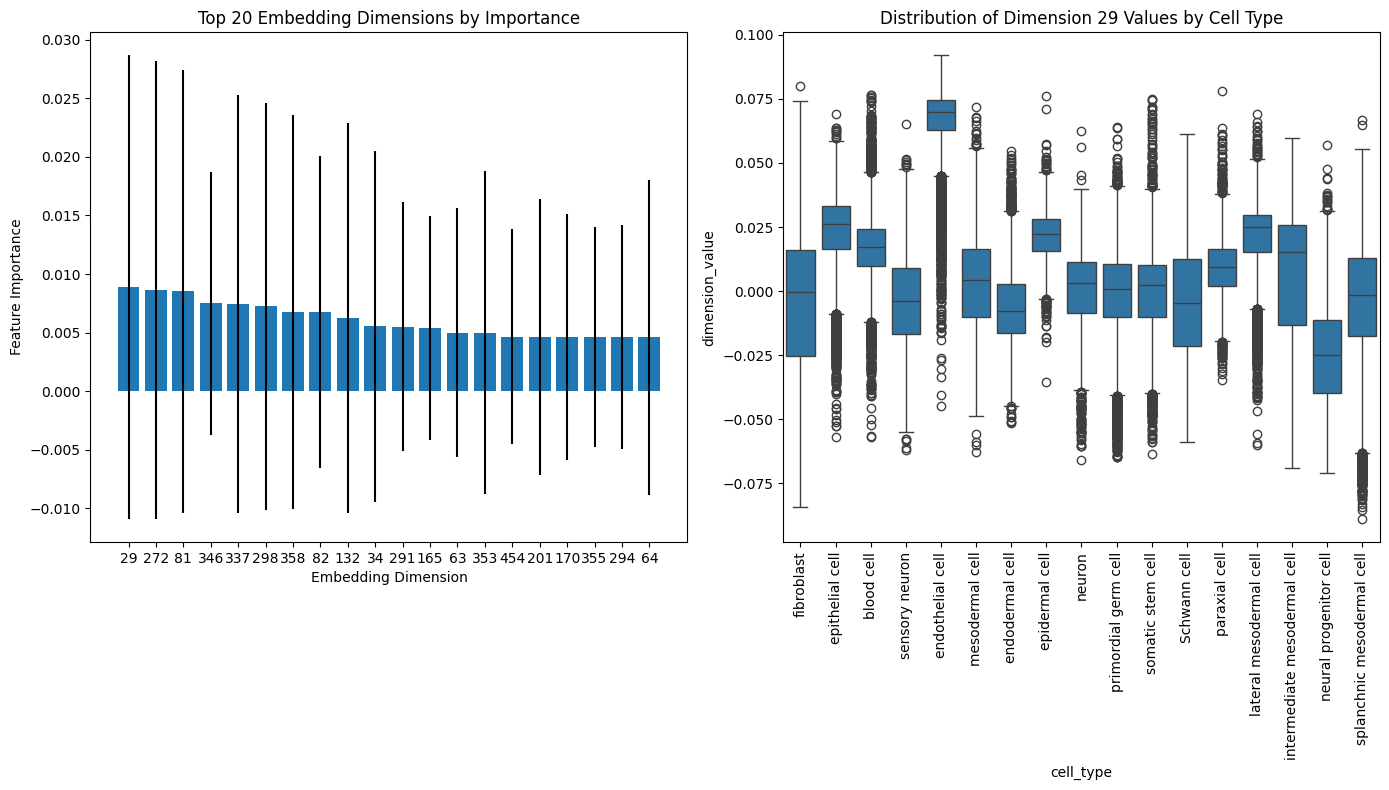

In [20]:
# Visualize top dimensions
plt.figure(figsize=(14, 8))

# Plot feature importances
plt.subplot(1, 2, 1)
top_n = 20
indices = dimension_analysis['importance_ranking'].head(top_n).index
plt.bar(range(top_n), 
        dimension_analysis['importance_ranking'].iloc[:top_n]['importance'],
        yerr=dimension_analysis['importance_ranking'].iloc[:top_n]['std'],
        align='center')
plt.xticks(range(top_n), dimension_analysis['importance_ranking'].iloc[:top_n]['dimension'])
plt.xlabel('Embedding Dimension')
plt.ylabel('Feature Importance')
plt.title('Top 20 Embedding Dimensions by Importance')

# Plot dimension distribution for top dimension
plt.subplot(1, 2, 2)
# Get data for top dimension
dim_idx = dimension_analysis['top_dimensions'][0]
dim_values = X_embed[:, dim_idx]
# Create DataFrame for easy plotting
plot_df = pd.DataFrame({
    'dimension_value': dim_values,
    'cell_type': y_celltype
})
# Plot boxplot
sns.boxplot(x='cell_type', y='dimension_value', data=plot_df)
plt.xticks(rotation=90)
plt.title(f'Distribution of Dimension {dim_idx} Values by Cell Type')
plt.tight_layout()
plt.show()

In [21]:
# Comprehensive classification analysis with error analysis
def run_ensemble_classification(X, y, donor_ids, test_donor, cell_types=None):
    """Run ensemble classification with detailed performance analysis"""
    # Prepare train/test split
    train_mask = donor_ids != test_donor
    test_mask = ~train_mask
    
    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]
    
    print(f"Training on {X_train.shape[0]} cells, testing on {X_test.shape[0]} cells")
    
    # Create and train ensemble classifier
    models = [
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('knn', KNeighborsClassifier(n_neighbors=10, n_jobs=-1))
    ]
    
    # Add LightGBM if available
    try:
        from lightgbm import LGBMClassifier
        models.append(('lgbm', LGBMClassifier(random_state=42, n_jobs=-1)))
        print("Using LightGBM in ensemble")
    except ImportError:
        print("LightGBM not available, using RF and KNN only")
    
    # Create and train ensemble
    ensemble = VotingClassifier(estimators=models, voting='soft')
    ensemble.fit(X_train, y_train)
    
    # Make predictions
    y_pred = ensemble.predict(X_test)
    y_proba = ensemble.predict_proba(X_test)
    
    # Calculate basic metrics
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Get class names if not provided
    if cell_types is None:
        cell_types = np.unique(y)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Error analysis
    errors = y_test != y_pred
    error_indices = np.where(errors)[0]
    error_rate = errors.mean()
    
    # Calculate confidence metrics
    confidence = np.max(y_proba, axis=1)
    correct_conf = confidence[~errors]
    error_conf = confidence[errors]
    
    # Most commonly confused classes
    error_pairs = list(zip(y_test[errors], y_pred[errors]))
    confusion_counts = pd.Series(error_pairs).value_counts().head(5)
    
    results = {
        'model': ensemble,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'error_rate': error_rate,
        'confusion_matrix': cm,
        'confusion_matrix_norm': cm_norm,
        'confidence_metrics': {
            'mean_confidence': np.mean(confidence),
            'correct_confidence': np.mean(correct_conf),
            'error_confidence': np.mean(error_conf),
            'confidence_gap': np.mean(correct_conf) - np.mean(error_conf)
        },
        'common_confusions': confusion_counts,
        'predictions': y_pred,
        'probabilities': y_proba,
        'errors': errors
    }
    
    return results

In [23]:
# Run classification using a selected test donor
test_donor = adata.obs['sample'].unique()[0]
X = adata.obsm['X_scGPT']
y = adata.obs['cell_type'].values
donor_ids = adata.obs['sample'].values

print(f"Running ensemble classification with donor '{test_donor}' as test set...")
classification_results = run_ensemble_classification(X, y, donor_ids, test_donor)

Running ensemble classification with donor 'SD34' as test set...
Training on 157109 cells, testing on 8976 cells
Using LightGBM in ensemble


c:\Users\annel\anaconda3\envs\scgpt_py39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.600455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130560
[LightGBM] [Info] Number of data points in the train set: 157109, number of used features: 512
[LightGBM] [Info] Start training from score -4.139050
[LightGBM] [Info] Start training from score -3.194877
[LightGBM] [Info] Start training from score -2.999105
[LightGBM] [Info] Start training from score -2.637906
[LightGBM] [Info] Start training from score -3.988100
[LightGBM] [Info] Start training from score -2.369433
[LightGBM] [Info] Start training from score -3.532406
[LightGBM] [Info] Start training from score -2.811984
[LightGBM] [Info] Start training from score -2.669738
[LightGBM] [Info] Start training from score -2.174040
[LightGBM] [Info] Start training from score -2.730736
[LightGBM] [Info] Start training from score -4.206362
[LightGBM] [Info] Start training from score -3.633591
[Ligh

c:\Users\annel\anaconda3\envs\scgpt_py39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\annel\anaconda3\envs\scgpt_py39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Classification Performance:
  Accuracy: 0.8068
  Balanced Accuracy: 0.7198
  Macro F1: 0.7152
  Weighted F1: 0.8084

Confidence Analysis:
  Mean confidence (correct predictions): 0.8456
  Mean confidence (incorrect predictions): 0.5741
  Confidence gap: 0.2715

Most Common Confusions:
  primordial germ cell → sensory neuron: 81 instances
  epithelial cell → endodermal cell: 76 instances
  endodermal cell → epithelial cell: 75 instances
  sensory neuron → primordial germ cell: 69 instances
  splanchnic mesodermal cell → epithelial cell: 62 instances


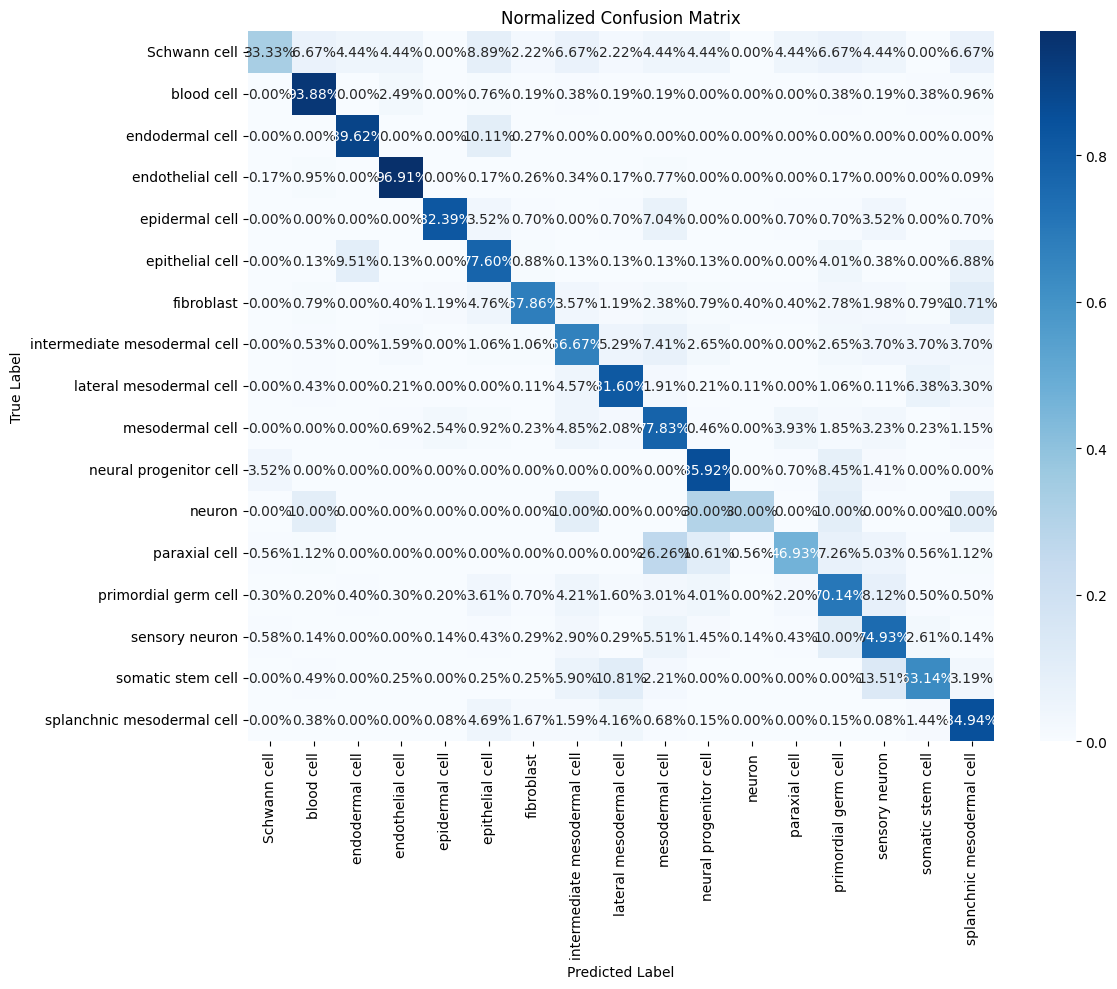

In [24]:
# Display results
print("\nClassification Performance:")
print(f"  Accuracy: {classification_results['accuracy']:.4f}")
print(f"  Balanced Accuracy: {classification_results['balanced_accuracy']:.4f}")
print(f"  Macro F1: {classification_results['macro_f1']:.4f}")
print(f"  Weighted F1: {classification_results['weighted_f1']:.4f}")

print("\nConfidence Analysis:")
conf_metrics = classification_results['confidence_metrics']
print(f"  Mean confidence (correct predictions): {conf_metrics['correct_confidence']:.4f}")
print(f"  Mean confidence (incorrect predictions): {conf_metrics['error_confidence']:.4f}")
print(f"  Confidence gap: {conf_metrics['confidence_gap']:.4f}")

print("\nMost Common Confusions:")
for (true_label, pred_label), count in classification_results['common_confusions'].items():
    print(f"  {true_label} → {pred_label}: {count} instances")

# Visualize confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(classification_results['confusion_matrix_norm'], 
            annot=True, fmt='.2%', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [25]:
# Visualize classification errors in embedding space
def visualize_classification_errors(adata, error_mask, method='umap'):
    """Visualize where classification errors occur in the embedding space"""
    # Create UMAP if it doesn't exist
    if 'X_umap' not in adata.obsm and method == 'umap':
        print("Computing UMAP projection...")
        import scanpy as sc
        sc.pp.neighbors(adata, use_rep='X_gene_embeddings')
        sc.tl.umap(adata)
    
    # Get embedding coordinates based on method
    if method == 'umap' and 'X_umap' in adata.obsm:
        embedding = adata.obsm['X_umap']
    elif method == 'tsne':
        if 'X_tsne' not in adata.obsm:
            print("Computing t-SNE projection...")
            from sklearn.manifold import TSNE
            adata.obsm['X_tsne'] = TSNE(n_components=2, random_state=42).fit_transform(adata.obsm['X_gene_embeddings'])
        embedding = adata.obsm['X_tsne']
    elif 'X_gene_embed_umap' in adata.obsm:
        # Use the gene embedding UMAP we created earlier
        embedding = adata.obsm['X_gene_embed_umap']
        print("Using gene embedding UMAP")
    else:
        # Use first two PCs
        if 'X_pca' not in adata.obsm:
            import scanpy as sc
            sc.pp.pca(adata)
        embedding = adata.obsm['X_pca'][:, :2]
        print("Using PCA (no UMAP found)")
    
    # Create interactive plot with Plotly
    df = pd.DataFrame({
        'UMAP1': embedding[:, 0],
        'UMAP2': embedding[:, 1],
        'Cell Type': adata.obs['cell_type'],
        'Donor': adata.obs['sample'],
        'Classification': ['Error' if e else 'Correct' for e in error_mask]
    })
    
    # Create figure
    fig = px.scatter(
        df, x='UMAP1', y='UMAP2', 
        color='Classification',
        color_discrete_map={'Correct': 'lightgrey', 'Error': 'red'},
        hover_data=['Cell Type', 'Donor'],
        opacity=0.7,
        title=f'Classification Errors in {method.upper()} Space'
    )
    
    fig.update_layout(
        width=900,
        height=700,
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    
    # Show the plot
    return fig

# For testing donor, create mask for the corresponding errors
full_error_mask = np.zeros(len(adata), dtype=bool)
test_indices = np.where(adata.obs['sample'] == test_donor)[0]
test_errors = classification_results['errors']

for i, idx in enumerate(test_indices):
    if i < len(test_errors) and test_errors[i]:
        full_error_mask[idx] = True

# Visualize errors using the gene embedding UMAP
print("Visualizing classification errors in embedding space...")
error_viz = visualize_classification_errors(adata, full_error_mask, method='umap')
# Display the figure (for notebook environment)
print("Error visualization plot created (displayed in notebook)")

Visualizing classification errors in embedding space...
Error visualization plot created (displayed in notebook)


In [ ]:
# Generate summary reports and save results

# Example usage of readable confusion matrix
results = plot_readable_confusion_matrix(
    classification_results['predictions'], 
    y[test_indices],
    f"Gene Embedding Classification - Donor {test_donor}")

In [43]:
# Save comprehensive analysis results
def save_comprehensive_analysis(adata, classification_results, embedding_quality_metrics, 
                               dimension_analysis, confusion_stats, save_dir=None):
    """
    Save a comprehensive record of your gene embedding analysis, including:
    1. The annotated data object with embeddings
    2. Classification performance metrics
    3. Embedding quality analysis
    4. Dimension importance analysis
    5. Confusion matrix and error analysis
    6. Visualization files
    7. A summary report in markdown format
    
    Parameters:
    -----------
    adata : AnnData
        The annotated data object with gene embeddings
    classification_results : dict
        Dictionary containing classification performance metrics
    embedding_quality_metrics : dict
        Dictionary containing embedding quality assessment
    dimension_analysis : dict
        Dictionary containing dimension importance analysis
    confusion_stats : dict
        Dictionary containing confusion matrix statistics
    save_dir : str, optional
        Directory to save results (defaults to 'gene_embeddings_analysis_results')
    """
    # Create timestamp for unique file naming
    from datetime import datetime
    import os
    import pickle
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Set up save directory
    if save_dir is None:
        save_dir = f"gene_embeddings_analysis_results_{timestamp}"
    
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "figures"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "tables"), exist_ok=True)
    
    print(f"Saving comprehensive analysis to: {save_dir}")
    
    # 1. Save the annotated data object
    # Option 1: Save as h5ad (standard AnnData format)
    adata_file = os.path.join(save_dir, "embedded_data.h5ad")
    print(f"Saving annotated data to: {adata_file}")
    adata.write(adata_file)
    
    # Option 2: Save using pickle (preserves all Python objects)
    pickle_file = os.path.join(save_dir, "embedded_data.pickle")
    with open(pickle_file, 'wb') as f:
        pickle.dump(adata, f)
    
    # 2. Save classification results
    if classification_results:
        # Save core metrics as CSV
        metrics = {
            'accuracy': [classification_results.get('accuracy', None)],
            'balanced_accuracy': [classification_results.get('balanced_accuracy', None)],
            'macro_f1': [classification_results.get('macro_f1', None)],
            'weighted_f1': [classification_results.get('weighted_f1', None)],
            'error_rate': [classification_results.get('error_rate', None)]
        }
        
        if 'confidence_metrics' in classification_results:
            for k, v in classification_results['confidence_metrics'].items():
                metrics[k] = [v]
        
        metrics_df = pd.DataFrame(metrics)
        metrics_df.to_csv(os.path.join(save_dir, "tables", "classification_metrics.csv"))
        
        # Save full classification results dictionary
        with open(os.path.join(save_dir, "classification_results.pickle"), 'wb') as f:
            pickle.dump(classification_results, f)
    
    # 3. Save embedding quality metrics
    if embedding_quality_metrics:
        quality_df = pd.DataFrame({k: [v] for k, v in embedding_quality_metrics.items()})
        quality_df.to_csv(os.path.join(save_dir, "tables", "embedding_quality.csv"))
    
    # 4. Save dimension analysis results
    if dimension_analysis and 'importance_ranking' in dimension_analysis:
        # Save dimension importance as CSV
        dimension_analysis['importance_ranking'].to_csv(
            os.path.join(save_dir, "tables", "dimension_importance.csv"))
        
        # Save full dimension analysis with pickle
        with open(os.path.join(save_dir, "dimension_analysis.pickle"), 'wb') as f:
            pickle.dump(dimension_analysis, f)
        
        # Create and save visualization of top dimensions
        if not os.path.exists(os.path.join(save_dir, "figures", "top_dimensions.png")):
            plt.figure(figsize=(12, 6))
            top_n = 20
            dims = dimension_analysis['importance_ranking'].head(top_n)
            plt.bar(range(top_n), dims['importance'], yerr=dims.get('std', None))
            plt.xlabel('Dimension Index')
            plt.ylabel('Importance Score')
            plt.title('Top 20 Important Embedding Dimensions')
            plt.xticks(range(top_n), dims['dimension'])
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, "figures", "top_dimensions.png"), dpi=300)
            plt.close()
    
    # 5. Generate and save a comprehensive summary report
    with open(os.path.join(save_dir, "analysis_summary.md"), 'w') as f:
        f.write(f"# Gene Embedding Analysis Summary\n\n")
        f.write(f"Analysis performed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write(f"## Dataset Information\n\n")
        f.write(f"- Number of cells: {adata.n_obs}\n")
        f.write(f"- Number of genes: {adata.n_vars}\n")
        f.write(f"- Embedding dimensions: {adata.obsm['X_gene_embeddings'].shape[1]}\n")
        f.write(f"- Number of cell types: {adata.obs['cell_type'].nunique()}\n")
        f.write(f"- Number of donors/samples: {adata.obs['sample'].nunique()}\n\n")
        
        f.write(f"## Embedding Quality\n\n")
        if embedding_quality_metrics:
            for metric, value in embedding_quality_metrics.items():
                f.write(f"- {metric}: {value:.4f}\n")
        
        f.write(f"\n## Classification Performance\n\n")
        if classification_results:
            f.write(f"- Accuracy: {classification_results.get('accuracy', 'N/A'):.4f}\n")
            f.write(f"- Balanced Accuracy: {classification_results.get('balanced_accuracy', 'N/A'):.4f}\n")
            f.write(f"- Macro F1: {classification_results.get('macro_f1', 'N/A'):.4f}\n")
            f.write(f"- Weighted F1: {classification_results.get('weighted_f1', 'N/A'):.4f}\n")
            
            if 'confidence_metrics' in classification_results:
                f.write(f"\n### Confidence Analysis\n\n")
                for metric, value in classification_results['confidence_metrics'].items():
                    f.write(f"- {metric}: {value:.4f}\n")
        
        f.write(f"\n## Top Embedding Dimensions\n\n")
        if dimension_analysis and 'importance_ranking' in dimension_analysis:
            f.write("| Dimension | Importance | Std |\n")
            f.write("|-----------|------------|-----|\n")
            for _, row in dimension_analysis['importance_ranking'].head(10).iterrows():
                f.write(f"| {int(row['dimension'])} | {row['importance']:.4f} | {row.get('std', 0):.4f} |\n")
        
        f.write(f"\n## Key Confusion Patterns\n\n")
        if confusion_stats and 'common_confusions' in classification_results:
            for (true_label, pred_label), count in classification_results['common_confusions'].items():
                f.write(f"- {true_label} → {pred_label}: {count} instances\n")
    
    print(f"Analysis successfully saved to {save_dir}")
    return save_dir

# Save comprehensive analysis with all results
try:
    save_path = save_comprehensive_analysis(
        adata=adata,
        classification_results=classification_results,
        embedding_quality_metrics=quality_metrics,
        dimension_analysis=dimension_analysis,
        confusion_stats=results
    )
    print(f"All analysis results saved to: {save_path}")
except Exception as e:
    print(f"Error saving analysis: {e}")
    

Saving comprehensive analysis to: gene_embeddings_analysis_results_20250228_200754
Saving annotated data to: gene_embeddings_analysis_results_20250228_200754\embedded_data.h5ad
Error saving analysis: 'X_gene_embeddings'


In [45]:
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\annel\OneDrive\Documenten\Machine Learning\scGPT\GenePT-tools\notebooks
